In [1]:
import pandas as pd
import numpy as np

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

from sksurv.datasets import load_whas500
from sksurv.ensemble import RandomSurvivalForest

set_config(display="text")

In [2]:
heart_attack_df, heart_attack_array = load_whas500()

In [3]:
heart_attack_df.head(5)

,afb,age,av3,bmi,chf,cvd,diasbp,gender,hr,los,miord,mitype,sho,sysbp
0,1,83.0,0,25.54051,0,1,78.0,0,89.0,5.0,1,0,0,152.0
1,0,49.0,0,24.02398,0,1,60.0,0,84.0,5.0,0,1,0,120.0
2,0,70.0,0,22.14290,0,0,88.0,1,83.0,5.0,0,1,0,147.0
3,0,70.0,0,26.63187,1,1,76.0,0,65.0,10.0,0,1,0,123.0
4,0,70.0,0,24.41255,0,1,85.0,0,63.0,6.0,0,1,0,135.0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(heart_attack_df, heart_attack_array, test_size = 0.20, random_state= 42)

In [5]:
rsf = RandomSurvivalForest(n_estimators= 1000, min_samples_split=10, 
                           min_samples_leaf= 5, n_jobs=-1, random_state=42)
'''
Experiment with the hyperparameters to get the ideal conditions.
'''
rsf.fit(X_train, y_train)

RandomSurvivalForest(min_samples_leaf=5, min_samples_split=10,
                     n_estimators=1000, n_jobs=-1, random_state=42)

In [6]:
'''
This is a test for the C_index. Anything between 0.7 and 0.8 is good and useful
'''
c_index = rsf.score(X_test, y_test)
f"{c_index:.5f}"

'0.74975'

In [7]:
'''
Sort the test avlues according to your factors of interest.
'''
D = X_test
X_test_df = pd.DataFrame(D)
X_test_sorted = X_test_df.sort_values(by=['age', 'chf'])
X_test_sel = pd.concat((X_test_sorted.head(3), X_test_sorted.tail(3)))

X_test_sel


,afb,age,av3,bmi,chf,cvd,diasbp,gender,hr,los,miord,mitype,sho,sysbp
72,0,35.0,0,38.59773,0,0,99.0,0,83.0,6.0,0,1,0,162.0
371,0,40.0,0,36.58072,0,0,62.0,0,95.0,3.0,0,0,0,113.0
193,0,43.0,0,24.21079,1,1,90.0,0,47.0,4.0,1,1,0,136.0
494,0,92.0,0,24.75240,1,1,114.0,1,92.0,3.0,1,0,0,216.0
491,0,93.0,0,23.02361,1,1,21.0,0,116.0,4.0,0,0,0,198.0
388,0,104.0,0,23.82665,1,0,53.0,1,92.0,3.0,0,0,0,126.0


In [8]:
pd.Series(rsf.predict(X_test_sel))

0      6.879039
1     16.077666
2     32.814542
3    117.125495
4    147.562746
5    161.535198
dtype: float64

In [9]:
import matplotlib.pyplot as plt

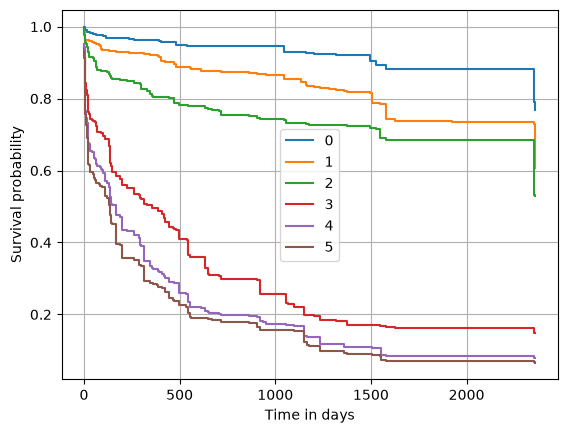

In [10]:
surv = rsf.predict_survival_function(X_test_sel, return_array=True)

for i,s in enumerate(surv):
    plt.step(rsf.unique_times_, s, where="post", label=str(i))
plt.ylabel("Survival probability")
plt.xlabel("Time in days")
plt.legend()
plt.grid(True)

In [11]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rsf, X_test, y_test, n_repeats=15, 
                                random_state=42)

In [12]:
pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test.columns,
).sort_values(by="importances_mean", ascending=False)

,importances_mean,importances_std
age,0.083035,0.022623
chf,0.052865,0.015974
bmi,0.027153,0.010736
hr,0.008511,0.011632
los,0.007768,0.004869
miord,0.006417,0.001761
sho,0.005989,0.001819
gender,0.002949,0.002134
sysbp,0.001801,0.005028
mitype,0.001734,0.003435
